# Week 2 — Day 1: Zero-shot BLIP captioning

Tasks:
- Conceptual: how multimodal models (BLIP/CLIP) fuse vision and text embeddings
- Set up Hugging Face BLIP (image captioning variant); run pretrained inference on 5–10 sample
  images with no fine-tuning (zero-shot)

Deliverable: notebook showing zero-shot BLIP captions on Flickr8k sample images with qualitative
comments.

## How BLIP fuses vision and text (brief)

BLIP uses a vision transformer (ViT) image encoder to turn an image into a sequence of patch
embeddings, and a text decoder (BERT-style, causal) that cross-attends to those image embeddings
while generating caption tokens autoregressively. Pretraining combines image-text contrastive
learning (like CLIP), image-text matching, and language-modeling objectives, so the same model can
both retrieve/rank image-text pairs and generate free-form captions. Here we use the captioning
head zero-shot — no fine-tuning on Flickr8k yet.

### 1. Load the pretrained BLIP captioning model

In [1]:
import os
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)
model.eval()
print("BLIP loaded.")

Using device: cpu


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

H:\intern_ICDA\voice_agent\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\umer\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP loaded.


### 2. Pick sample images and their ground-truth captions

In [2]:
captions_path = '../data/captions.txt'
img_dir = '../data/Images'

df = pd.read_csv(captions_path)
df.columns = ['image', 'caption']

sample_images = df['image'].drop_duplicates().sample(8, random_state=7).tolist()
gt_captions = {img: df[df['image'] == img]['caption'].iloc[0] for img in sample_images}
sample_images

['3636491114_ab34dac833.jpg',
 '2741051940_89fb6b2cee.jpg',
 '469259974_bb03c15c42.jpg',
 '3169591322_d0b6d0cd04.jpg',
 '2102732029_9ae520914d.jpg',
 '357191373_a1cb5696e8.jpg',
 '3396043950_12783c5147.jpg',
 '3100442775_6e2659b973.jpg']

### 3. Generate zero-shot captions

In [3]:
@torch.no_grad()
def generate_caption(img_path):
    image = Image.open(img_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30)
    return processor.decode(out[0], skip_special_tokens=True)

results = []
for img_name in sample_images:
    pred = generate_caption(os.path.join(img_dir, img_name))
    results.append({
        "image": img_name,
        "predicted_caption": pred,
        "ground_truth_caption": gt_captions[img_name],
    })

results_df = pd.DataFrame(results)
results_df

,image,predicted_caption,ground_truth_caption
0,3636491114_ab34dac833.jpg,a man swimming in a pool,A person doing the backstroke in an outdoor po...
1,2741051940_89fb6b2cee.jpg,a small pig,a chubby puppy dog with its tail cut off plays...
2,469259974_bb03c15c42.jpg,man reading newspaper,A man drinking and reading the paper .
3,3169591322_d0b6d0cd04.jpg,a man doing a trick on a skateboard,A man performs a skateboard trick in a parking...
4,2102732029_9ae520914d.jpg,a little girl taking a picture,One girl is helping another to take a picture ...
5,357191373_a1cb5696e8.jpg,a group of people riding horses through a forest,A group of people ride horses through a wooded...
6,3396043950_12783c5147.jpg,a group of people,A boy wearing a white apron has is arms out in...
7,3100442775_6e2659b973.jpg,a man on a skateboard,A BMW rider takes a large jump off a wall .


### 4. Visual comparison: image, prediction, ground truth

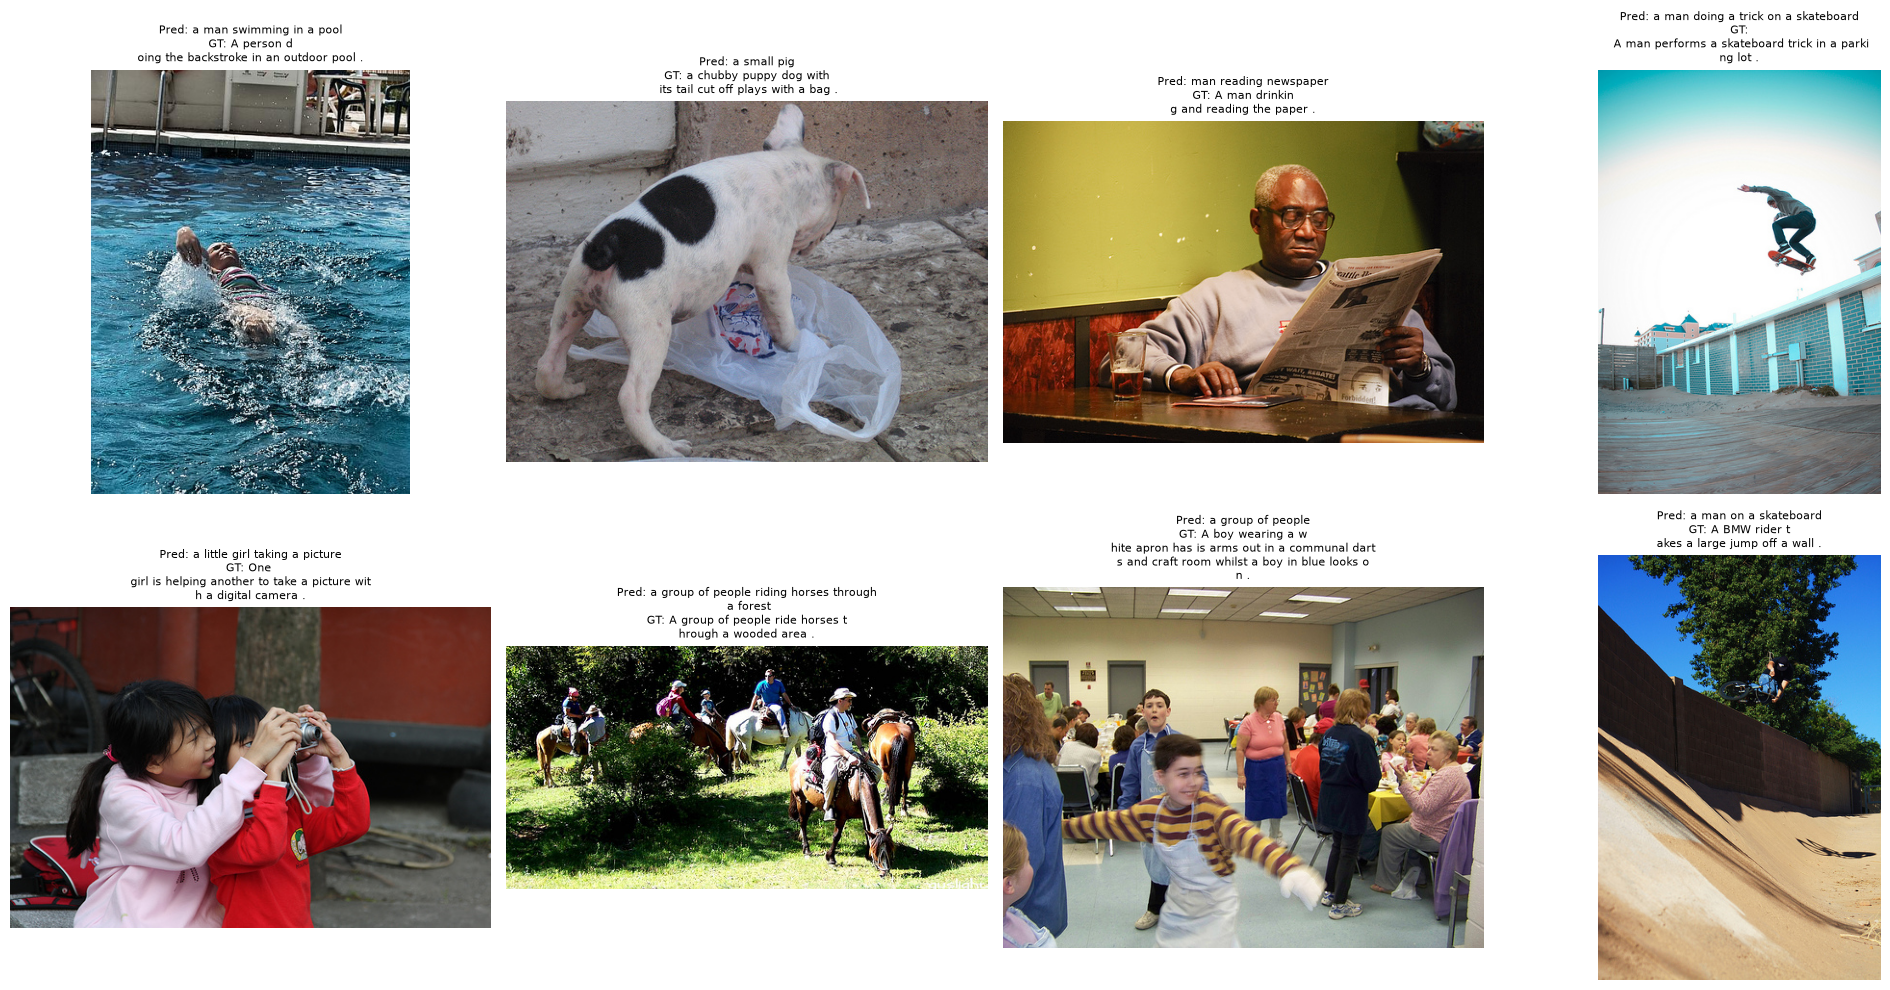

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, row in zip(axes.flat, results):
    img = Image.open(os.path.join(img_dir, row["image"])).convert('RGB')
    ax.imshow(img)
    title = f"Pred: {row['predicted_caption']}\nGT: {row['ground_truth_caption']}"
    wrapped = '\n'.join([title[i:i+45] for i in range(0, len(title), 45)])
    ax.set_title(wrapped, fontsize=8)
    ax.axis('off')
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/week2_zero_shot_blip_grid.png', dpi=120)
plt.show()

### Qualitative comments

Observed on this 8-image sample (see grid and table above):

- **Generally accurate on the main subject and action**: a man skateboarding, a man reading a
  newspaper, people on horseback, a girl taking a picture were all captioned correctly and
  concisely.
- **Shorter and more generic than the human captions**: BLIP's zero-shot captions rarely mention
  color, clothing, or setting detail that Flickr8k's human annotators include (e.g., "a group of
  people" vs. the ground truth "A boy wearing a white apron...").
- **One clear misclassification**: a puppy was captioned as "a small pig" — the model got the
  general shape/pose right (small four-legged animal) but the category wrong. This is a good
  candidate to revisit in Week 3's XAI analysis (Grad-CAM) to see what region of the image drove
  that decision.
- These patterns (terse captions, occasional category confusion) motivate the BLEU/ROUGE
  quantitative evaluation on Day 2, and the correct-vs-incorrect case comparison in Week 3.